In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

### Let us now try to load a random dataset and the one I've picked for this illustration is Sample_Superstore dataset. 

### What It Is

The Sample ‑ Superstore dataset is a simulated retail sales dataset that represents purchase transactions from a fictional “Superstore” in the United States. It mimics real business operations including orders, shipping, customer segments, product hierarchies, and financial results. This dataset has become a de facto standard for learning exploratory data analysis (EDA), visualization, SQL querying, BI tools (like Tableau/Power BI), and machine learning preprocessing because it includes a mix of numerical and categorical variables with realistic patterns.

In [2]:
# Loading Pandas DataFrame:
df = pd.read_csv(
    r"D:\datasets\Sample - Superstore.csv",
    encoding="latin1"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.shape

(9994, 21)

In [4]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

### df.isnull()
creates a True/False table where True indicates a missing value (NaN) in the dataset.
.sum() adds up the True values column-wise so you get the count of missing values per column.
No missing values in the dataset. 
Every row in every column has valid data.

In [6]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


### check data types

In [7]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

### convert into valid data types

In [8]:
df['Order Date']=pd.to_datetime(df['Order Date'])   
df['Ship Date']=pd.to_datetime(df['Ship Date']) 

### Convert discount into percentage

In [9]:
df['Discount']=df['Discount']/100

In [10]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

### Number of Orders by Region

In [11]:
# Count how many orders come from each Region
orders_by_region = df['Region'].value_counts()
print("Orders by Region:\n", orders_by_region)


Orders by Region:
 Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64


### df['Region'].value_counts() shows how many orders there are from each region.
This lets us see which regions have the highest number of orders, helping us understand where most of the business is coming from. We can use this to spot trends in regional demand or figure out which regions are contributing the most to sales.

### Total Sales & Profit by Category

In [12]:
# Group the data by Category and sum Sales & Profit
category_sales_profit = df.groupby('Category')[['Sales', 'Profit']].sum()
print("Total Sales and Profit by Category:\n", category_sales_profit)


Total Sales and Profit by Category:
                        Sales       Profit
Category                                 
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008
Technology       836154.0330  145454.9481


### Explanation
Using groupby('Category') puts all the data into groups based on the product category like Furniture, Technology, or Office Supplies.
Then, [['Sales', 'Profit']].sum() adds up the total sales and profit for each category.
This helps us see which category makes the most money and which one is the most profitable—or maybe even causing losses

### Top 10 Customers by Sales

In [13]:
# Group by Customer Name and sum Sales, then sort descending to get top 10
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
print("Top 10 Customers by Sales:\n", top_customers)


Top 10 Customers by Sales:
 Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


### Correlation Between Sales and Profit

In [14]:
# Calculate correlation between Sales and Profit
correlation = df[['Sales', 'Profit']].corr()
print("Correlation between Sales and Profit:\n", correlation)


Correlation between Sales and Profit:
            Sales    Profit
Sales   1.000000  0.479064
Profit  0.479064  1.000000


### # --- Visualizations ---

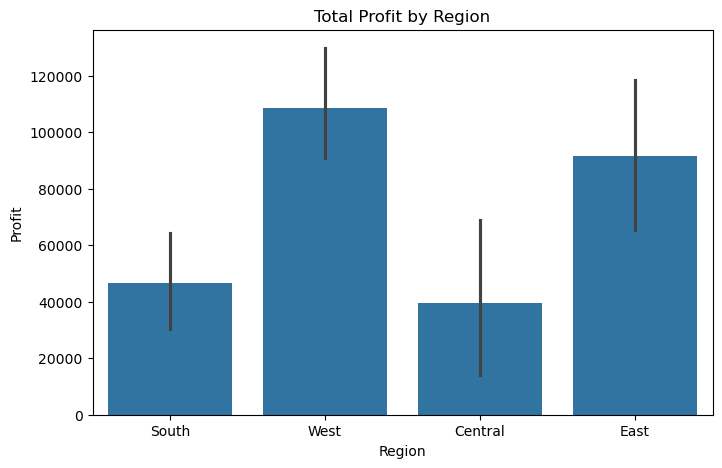

In [15]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Region', y='Profit', estimator=sum)
plt.title('Total Profit by Region')
plt.show()


### bar chart 
This bar chart shows the total profit generated in each region. Each bar represents a region, and its height corresponds to the sum of profits from all orders in that region. It’s an easy way to see which regions are performing well and which are lagging in profitability.

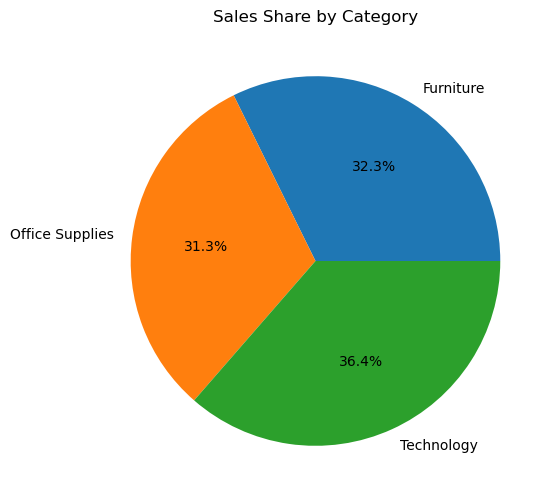

In [16]:
plt.figure(figsize=(6,6))
df.groupby('Category')['Sales'].sum().plot.pie(autopct='%1.1f%%')
plt.title('Sales Share by Category')
plt.ylabel('')
plt.show()


###
This pie chart shows how total sales are distributed across product categories. Each slice represents a category, and its size reflects the proportion of overall sales it contributes. It gives a quick visual sense of which categories drive the most revenue.

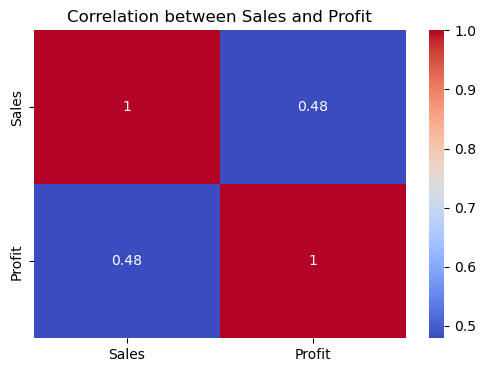

In [17]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Sales', 'Profit']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between Sales and Profit')
plt.show()

### 
This heatmap shows the correlation between Sales and Profit. The numbers indicate how strongly the two variables are related, with values closer to 1 meaning a strong positive relationship. It helps quickly understand whether higher sales generally lead to higher profits.

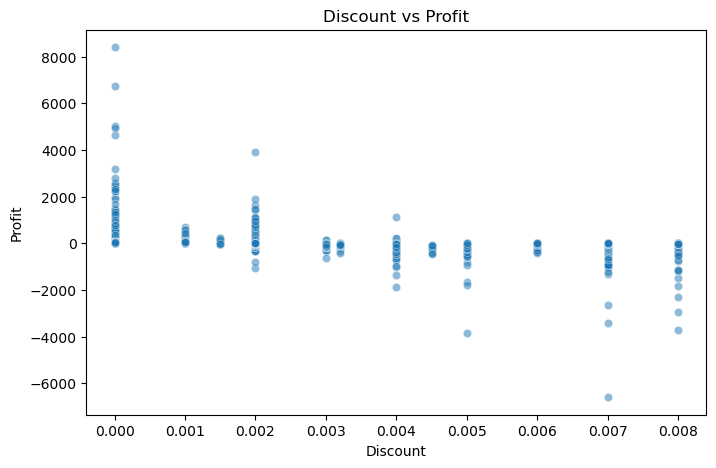

Discount vs Profit correlation:
           Discount    Profit
Discount  1.000000 -0.219487
Profit   -0.219487  1.000000


In [18]:
# --- Discount vs Profit Analysis ---
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5)
plt.title('Discount vs Profit')
plt.show()

# Additional stats
print("Discount vs Profit correlation:\n", df[['Discount', 'Profit']].corr())

### 
This scatter plot visualizes how profit changes with different discount levels. Each dot represents an order, showing the discount given and the profit earned. You can quickly see if giving bigger discounts tends to reduce profits or if some orders remain profitable despite discounts. The correlation value provides a numeric measure of this relationship, helping understand the overall trend.

### Highlight trends:
Point out if there's a clear pattern for example higher discounts often lead to lower profits, but some high-discount orders are still profitable.

### Business implication: 
Explain what it could mean: This suggests careful discount strategies are needed to maximize profit.

### Outliers:
Mention any unusual points: A few orders with large discounts still have high profits—these could be special cases or bulk deals.

### Decision insight:
Encourage users to think: Managers could analyze these patterns to optimize pricing and discount policies.

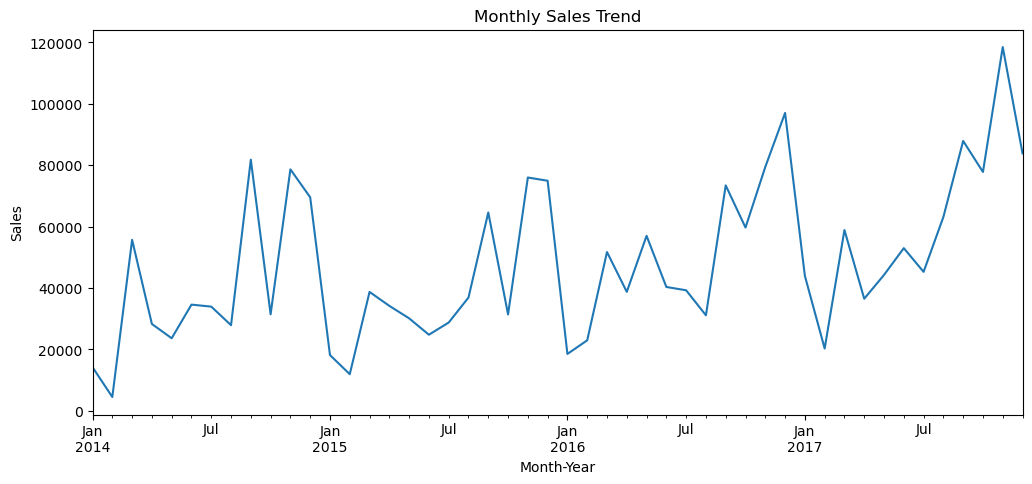

In [19]:
#  Sales Trend over time
# Convert 'Order Date' to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Group by month-year and sum sales
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title('Monthly Sales Trend')
plt.xlabel('Month-Year')
plt.ylabel('Sales')
plt.show()

### 
This line chart shows the monthly sales trend over time. Each point represents the total sales in a given month, allowing us to see how sales rise or fall throughout the year. It helps identify seasonal patterns, growth trends, or slow periods, giving insights into when the store performs best and when it might need extra marketing or promotions

### Seasonal insights:
Point out months with unusually high or low sales Notice how sales peak in November and December, likely due to holiday shopping.

### Trend interpretation:
Highlight overall direction Overall, sales are steadily increasing over the years, showing business growth.

### Anomalies:
Mention unusual spikes or drops There’s a sudden drop in March this could be due to promotions ending or other factors.

### Business implication: 
Suggest what to do with the insight Management can plan inventory and marketing campaigns around peak months.

In [20]:
# --- Cell 9: Business Insights (Markdown) ---
"""
From the analysis, we observe:

- The Western region generates the highest total profit.
- The Office Supplies category, especially in some regions, shows low or negative profitability and could be optimized.
- Several sub-categories are consistently loss-making and should be reviewed.
- There is a negative correlation between Discount and Profit, suggesting heavy discounts may reduce profitability.
- Monthly sales trend shows seasonal variation that could help in planning inventory and marketing.

These insights can help the business focus on high-profit regions and categories while optimizing or reevaluating low-performing segments.
"""

     

'\nFrom the analysis, we observe:\n\n- The Western region generates the highest total profit.\n- The Office Supplies category, especially in some regions, shows low or negative profitability and could be optimized.\n- Several sub-categories are consistently loss-making and should be reviewed.\n- There is a negative correlation between Discount and Profit, suggesting heavy discounts may reduce profitability.\n- Monthly sales trend shows seasonal variation that could help in planning inventory and marketing.\n\nThese insights can help the business focus on high-profit regions and categories while optimizing or reevaluating low-performing segments.\n'

### Top 20 Customers Contributing the Highest Profit to the Store

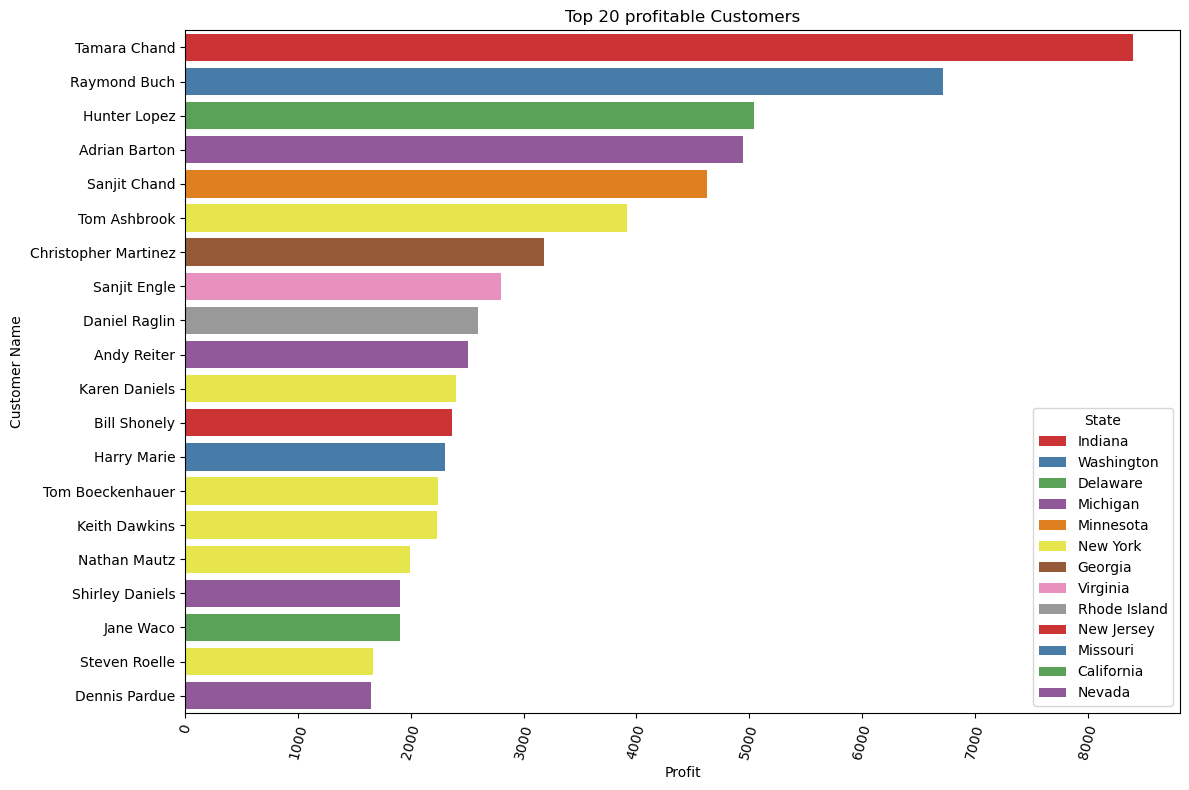

In [21]:
#Top 20 Customers who benefitted the store
# Sort the dataset by Profit in descending order
# and select the top 20 most profitable customers
sortedTop20 = df.sort_values(['Profit'], ascending=False).head(20)
fig = plt.figure(figsize=(12,8))
# Add a single subplot (1 row, 1 column, first plot)
ax = fig.add_subplot(111)
p = sns.barplot(y='Customer Name', x='Profit',hue='State',palette='Set1', data=sortedTop20, ax=ax)
ax.set_title("Top 20 profitable Customers")
ax.set_xticklabels(p.get_xticklabels(), rotation=75) # Rotate x-axis labels to avoid overlapping and improve readability
plt.tight_layout() # Adjust layout so labels and title fit properly within the figure
plt.show()

### This chart displays the top 20 customers ranked by total profit generated for the store.
Each bar represents a customer’s profit contribution, while colors indicate the state they belong to.
The visualization helps identify high value customers and understand regional profit distribution.

### 
This visualization clearly highlights the top 20 customers contributing the highest profit to the store, with state-wise differentiation to support informed business and regional performance analysis.

### Discount

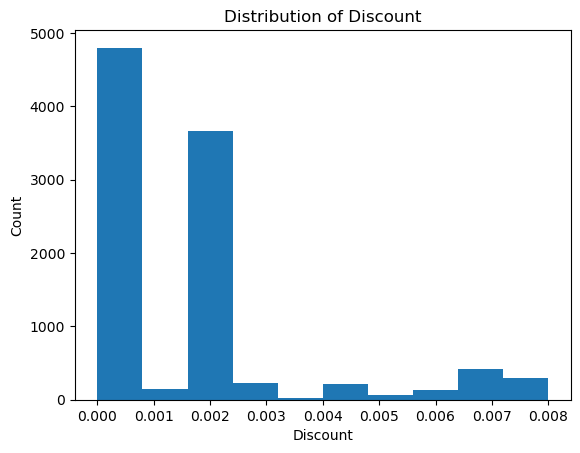

In [26]:
plt.hist(x='Discount',data=df)
plt.title('Distribution of Discount')
plt.xlabel('Discount')
plt.ylabel('Count')
plt.show()

###
This histogram shows how discounts are distributed in the dataset. The x-axis represents the discount values, and the y-axis shows how many orders fall into each discount range. It helps us understand which discount levels are most common and whether higher or lower discounts are used more frequently.

### Comparison of loss by region

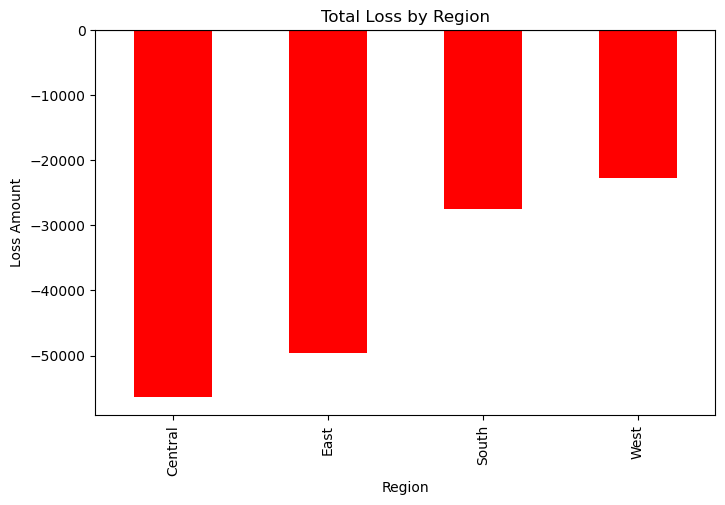

In [39]:


# Filter only loss-making records
loss_df = df[df['Profit'] < 0]

# Calculate total loss by region
loss_by_region = loss_df.groupby('Region')['Profit'].sum()

# Plot all regions with loss
plt.figure(figsize=(8,5))
loss_by_region.plot(kind='bar', color='red')
plt.title('Total Loss by Region')
plt.xlabel('Region')
plt.ylabel('Loss Amount')
plt.axhline(0, color='black')  # separates profit/loss visually
plt.show()

### 
This code calculates the total loss for all regions by summing only the negative profit values and displays it in a bar chart. It helps quickly see which regions are losing the most, making it easy to compare losses across all regions.

In [41]:
# Total loss across all regions
total_loss = df[df['Profit'] < 0]['Profit'].sum()
print("Total Loss Across All Regions:", total_loss)

Total Loss Across All Regions: -156131.2857


### Top loss  making products and categories by region 

In [42]:
# 1. Filter only loss-making orders
loss_df = df[df['Profit'] < 0]
# 2. Group by Region and Category (or Product) and sum the loss
loss_by_region_category = loss_df.groupby(['Region', 'Category'])['Profit'].sum().sort_values()

# 3. Display top loss contributors
print("Top Loss Contributors by Region and Category:")
print(loss_by_region_category)
# Optional: If you want to see top 5 loss-making products in each region
top_loss_products = loss_df.groupby(['Region', 'Product Name'])['Profit'].sum().sort_values()
print("\nTop Loss-Making Products by Region:")
print(top_loss_products.head(10))

Top Loss Contributors by Region and Category:
Region   Category       
Central  Office Supplies   -33484.1655
East     Technology        -20997.6322
Central  Furniture         -19554.3653
East     Furniture         -18801.7854
West     Furniture         -12657.9337
South    Furniture          -9922.0246
East     Office Supplies    -9791.1899
South    Office Supplies    -9713.5112
         Technology         -7869.2965
West     Technology         -6436.6353
         Office Supplies    -3626.3919
Central  Technology         -3276.3542
Name: Profit, dtype: float64

Top Loss-Making Products by Region:
Region   Product Name                                                               
East     Cubify CubeX 3D Printer Double Head Print                                     -9239.9692
Central  GBC DocuBind P400 Electric Binding System                                     -5552.8392
South    Cubify CubeX 3D Printer Triple Head Print                                     -3839.9904
Central  Fellowe

#### 
First we pick out all the orders where the business lost money—basically anything with negative profit.



### 
Then, we group these loss-making orders by region and product category (or even by individual product) to see which areas or products are causing trouble.



### 
Next, we add up all the losses in each group so we can get a clear total for each region or product.
After that, we sort the numbers to quickly spot the biggest problem areas—the regions or products losing the most money.
Finally, this gives us insight into where the losses are happening, so we know what to fix, like adjusting pricing, reducing discounts, or managing stock better.

### Insights

### 
The Western region yields the highest profit among all.
The Office Supplies category in the Southern region shows low profitability.
Some sub-categories are consistently loss-making, requiring a strategic review.
A negative correlation is observed between high discount rates and profit margins.
### Recommendation
* Focus on Technology categories like copies,accessories and phones as they are highest selling and most profitable
* selling bookcase tables and supplies result in losses so i suggest superstore to consider bundling them together with high profitable sub category like copies accessories
* Home office customers might be too busy with work and less likely to spend time selecting products individually. so i recommended creating a home office  catlog with products used for offices such as paper , chairs etc ... machines would be result in better profits
* Among every region west and east region recordedmore profit . So strategy should focus more on east and west region
   

### Discount Impact
* High discounts in loss-making regions products are a key reason for losses.
* Maintaining discounts in profitable regions products is still recommended as they drive sales without hurting
### Business Recommendations
* Reduce or modify discounts only in regions and categories causing losses.
* Keep discounts in profitable regions products to maintain sales momentum.
* Monitor sales and profit continuously after adjustments to fine-tune the strategy.
* Investigate high-loss products or regions further for operational or pricing improvements.  

### Decision
* Do not stop giving discounts everywhere.
* Adjust discounts strategically based on region and product performance.